## 25.10.28: Keypoint Mask Clustering + Graph based methods

In [1]:
import sys, os, json
sys.path.append(os.path.abspath('..'))

from tqdm import tqdm
from itertools import pairwise
from copy import deepcopy

import numpy as np
import scipy
from scipy.spatial import Delaunay

import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import cv2
from ultralytics import YOLO

from sklearn.cluster import AffinityPropagation, DBSCAN, MeanShift
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import RANSACRegressor

from scripts.classes.pitch import Pitch, PitchKeypointMapping, HomographySolver
from scripts.classes.frame import FrameNumpy

from scripts.datasets.calibration import CalibrationDataset, CalibrationLabelsMapping
from scripts.datasets.field_masking import MaskingCalibrationDataset
from scripts.datasets.field_pitch import PitchCalibrationDataset, PitchKeypointCalibrationDataset
from SoccerNet.Downloader import SoccerNetDownloader

print(f'Torch CUDA availability: {torch.cuda.is_available()}')
print(f'Torch MPS availability: {torch.mps.is_available()}')

WIDTH, HEIGHT = 320, 180

Torch CUDA availability: False
Torch MPS availability: True


/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
calibration_train_dataset = CalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128, centered=True,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
calibration_test_dataset = CalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128, centered=True,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
calibration_valid_dataset = CalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128, centered=True,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(calibration_train_dataset)}')
print(f'Number of test samples: {len(calibration_test_dataset)}')
print(f'Number of valid samples: {len(calibration_valid_dataset)}')

Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


In [3]:
masking_calibration_train_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128, keypoint_only=True,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_test_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128, keypoint_only=True,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_valid_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128, keypoint_only=True,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))

print(f'Number of training samples: {len(masking_calibration_train_dataset)}')
print(f'Number of test samples: {len(masking_calibration_test_dataset)}')
print(f'Number of valid samples: {len(masking_calibration_valid_dataset)}')

Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


In [4]:
pitch_keypoint_calibration_train_dataset = PitchKeypointCalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
pitch_keypoint_calibration_test_dataset = PitchKeypointCalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
pitch_keypoint_calibration_valid_dataset = PitchKeypointCalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(pitch_keypoint_calibration_train_dataset)}')
print(f'Number of test samples: {len(pitch_keypoint_calibration_test_dataset)}')
print(f'Number of valid samples: {len(pitch_keypoint_calibration_valid_dataset)}')

Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


## UNet

https://arxiv.org/abs/2504.14131

In [5]:
class KeypointHeatmap(nn.Module):
    def __init__(self):
        super().__init__()
        self.unet = torch.hub.load('sm00thix/unet', 'unet', pretrained=False, in_channels=1, out_channels=1, pad=True, bilinear=True, normalization='bn')
        self.eps = 1e-6

    def forward(self, x):
        # x: [N x 1 x H x W]
        x = self.unet(x)
        min_x = torch.amin(x, dim=(-1, -2), keepdim=True) 
        max_x = torch.amax(x, dim=(-1, -2), keepdim=True) 
        return (x - min_x + self.eps) / (max_x - min_x + self.eps)

In [6]:
DEVICE = torch.device('cpu')
torch.mps.empty_cache()

torch.hub.load('sm00thix/unet', 'unet', pretrained=False, in_channels=1, out_channels=1, pad=True, bilinear=True, normalization='bn')
unet_seg_model = torch.load('../weights/experimental/251006-unet-model.pt').to(DEVICE)
unet_keypoint_model = torch.load('../weights/experimental/251026-unet-keypoint-model.pt').to(DEVICE)
unet_seg_model.eval()
unet_keypoint_model.eval()

print(f'UNet model device: {next(unet_seg_model.parameters()).device}')

Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main
/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_15078/429008146.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this ex

UNet model device: cpu


In [7]:
def plot_test_unet_seg():
    torch.mps.empty_cache()

    batch_size = 16
    valid_dataloader = DataLoader(masking_calibration_valid_dataset, batch_size=batch_size, shuffle=False)
    img, mask = next(iter(valid_dataloader))
    img = img.float().unsqueeze(1).to(DEVICE)
    mask = mask.float().unsqueeze(1).to(DEVICE)

    unet_seg_model.eval()
    seg_mask = unet_seg_model(img)
    out_mask = unet_keypoint_model(seg_mask)
    print(f'img.shape = {img.shape}, out_mask.shape = {out_mask.shape}, mask.shape = {mask.shape}')

    img = img.to('cpu')
    mask = img.to('cpu')

    fig, axes = plt.subplots(nrows=batch_size, ncols=3, figsize=(15, 50))
    def img_convert(img):
        return img.permute((1, 2, 0)).cpu().detach().numpy()

    for idx in range(batch_size):
        axes[idx, 0].imshow(img_convert(img[idx]), cmap='gray')
        axes[idx, 1].imshow(img_convert(seg_mask[idx]), cmap='gray')
        axes[idx, 2].imshow(img_convert(out_mask[idx]), cmap='gray')

    axes[0, 0].set_title('Input')
    axes[0, 1].set_title('UNet Segmentation')
    axes[0, 2].set_title('UNet Keypoint Detector')

    fig.tight_layout()
    plt.show()

# plot_test_unet_seg()

## Clustering methods

In [40]:
def keypoint_detector(img, threshold=0.8, offset=np.array([0, 0, 0])):
    pts = torch.nonzero(img > threshold)
    clustering = MeanShift(bandwidth=8).fit(pts)
    X = clustering.cluster_centers_[:, [0, 1]]
    X = np.hstack([X, np.ones((X.shape[0], 1))])
    return X + offset

In [41]:
def plot_clustering_mask(n, threshold=.8):
    fig, axes = plt.subplots(ncols=3, nrows=n, figsize=(18, 5 * n))

    for idx in range(n):
        _, labels = calibration_valid_dataset[idx]
        pitch = Pitch.from_one_annotation(labels=labels, return_none_if_bad_annotation=False)
        pitch.plot(axes[idx, 2], scale=2, thickness=5)

        keypoints = keypoint_detector(out_mask[idx][0], threshold=threshold)
        axes[idx, 0].imshow(img[idx][0].detach().numpy(), cmap='gray')
        axes[idx, 1].imshow(seg_mask[idx][0].detach().numpy(), cmap='gray')
        axes[idx, 0].scatter(x=keypoints[:, 1], y=keypoints[:, 0], color='r', alpha=0.8)
        axes[idx, 1].scatter(x=keypoints[:, 1], y=keypoints[:, 0], color='r', alpha=0.8)

    plt.tight_layout()
    plt.show()

# plot_clustering_mask(n=batch_size)
# plot_clustering_mask(n=4)

tensor([[ 1.3974e+02,  1.4659e+03,  1.0000e+00],
        [ 2.6786e+02,  1.8617e+03,  1.0000e+00],
        [ 7.2131e+01,  1.2571e+03,  1.0000e+00],
        [ 9.2171e+01,  9.0216e+02,  1.0000e+00],
        [ 2.2852e+02,  2.5182e+03,  1.0000e+00],
        [-4.0253e+01,  1.1101e+02,  1.0000e+00],
        [ 1.3354e+02, -6.5857e+02,  1.0000e+00],
        [ 1.6109e+02,  8.7822e+03,  1.0000e+00],
        [-2.1298e+02, -1.1893e+03,  1.0000e+00],
        [-2.0266e+01,  9.7174e+02,  1.0000e+00],
        [-1.2185e+03, -2.7292e+03,  1.0000e+00],
        [-2.1362e+01,  2.7360e+01,  1.0000e+00],
        [-1.3188e+01,  2.1205e+02,  1.0000e+00],
        [ 5.3852e+01, -3.0571e+02,  1.0000e+00],
        [ 9.3880e+01, -8.4722e+01,  1.0000e+00],
        [ 3.3596e+02,  8.1011e+03,  1.0000e+00],
        [-9.7946e+02, -2.1621e+04,  1.0000e+00],
        [-3.4467e+02, -2.5059e+03,  1.0000e+00],
        [-2.4088e+02, -1.9329e+03,  1.0000e+00],
        [-7.6976e+00, -3.3147e+01,  1.0000e+00],
        [-4.1503e+00

(180.0, -180.0)

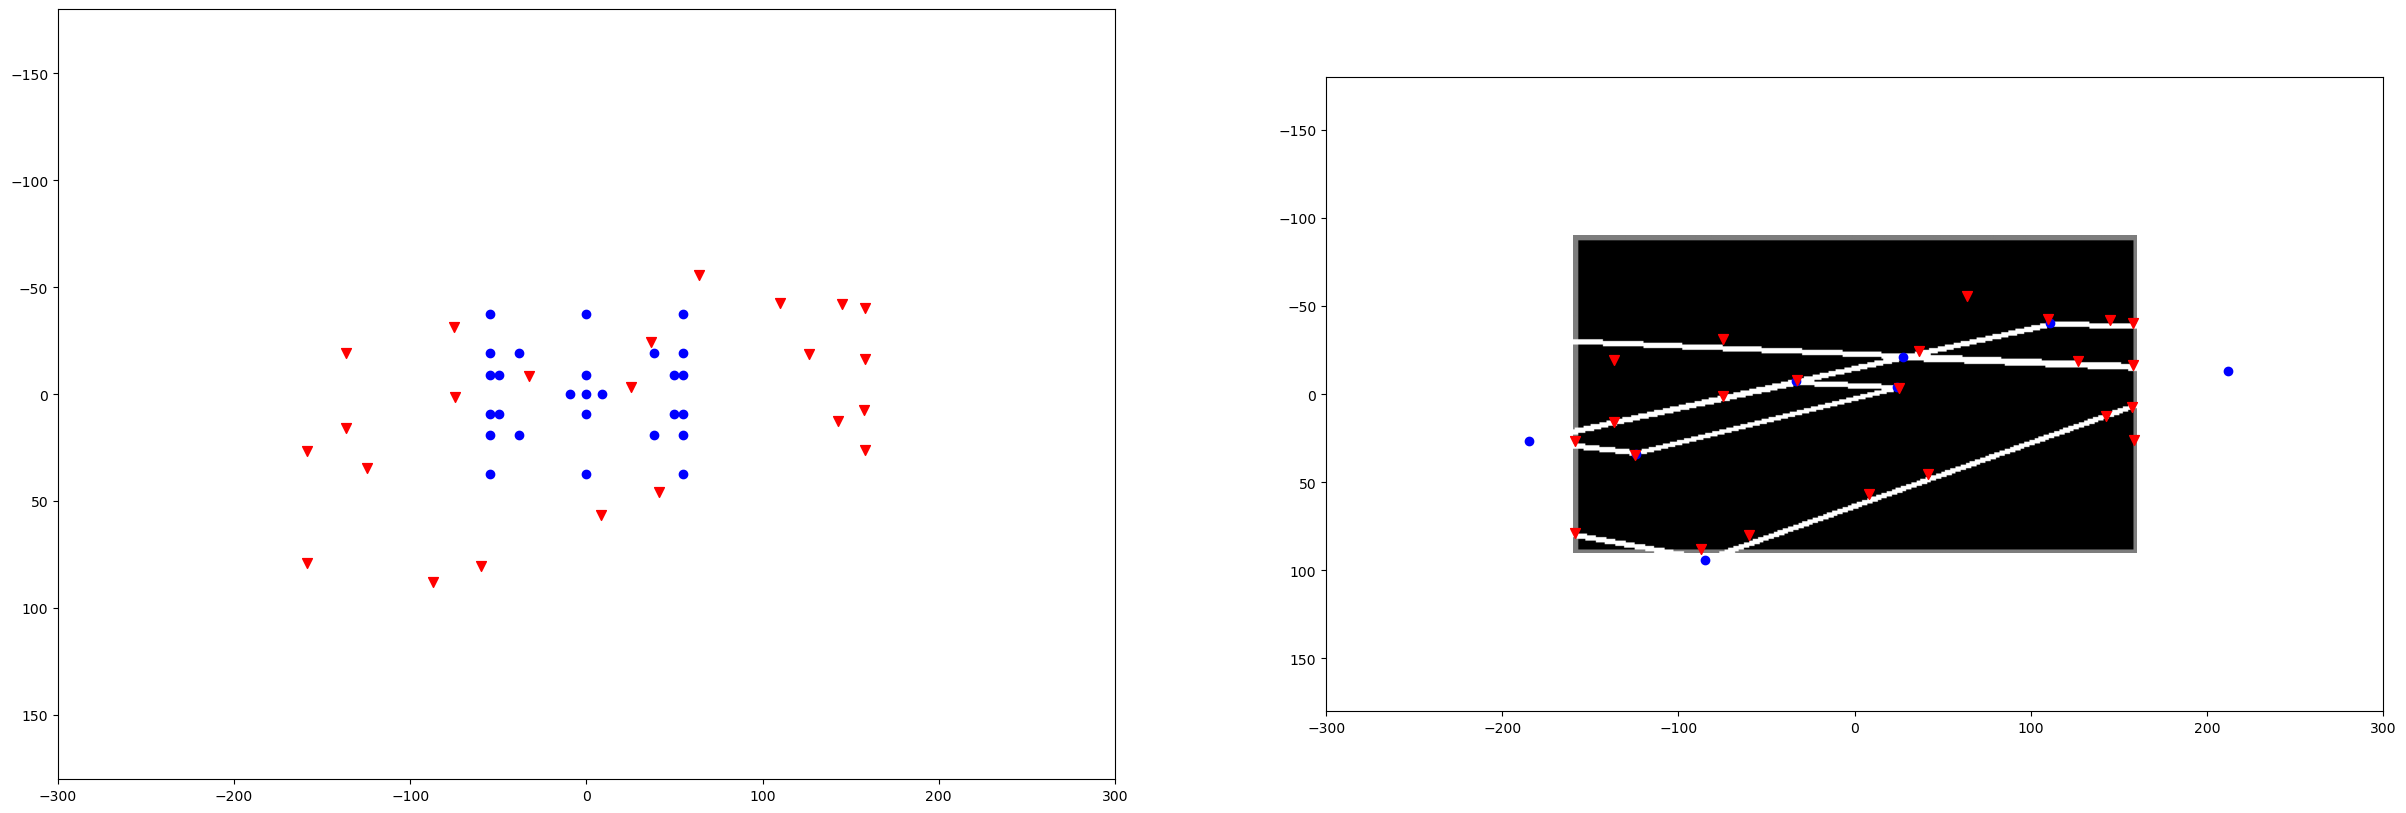

In [87]:
IDX = 8
img, labels = calibration_valid_dataset[IDX]

seg_mask = unet_seg_model(torch.Tensor(img).unsqueeze(0).unsqueeze(1))
out_mask = unet_keypoint_model(seg_mask)
keypoint_mask = unet_keypoint_model(seg_mask)

seg_mask = seg_mask.detach().numpy()[0][0]
keypoint_mask = keypoint_mask.detach().numpy()[0][0]

original_pitch = Pitch()
original_pitch_keypoints = original_pitch.keypoints.detach()
original_pitch_keypoints /= original_pitch_keypoints[:, 2].unsqueeze(1)

pitch = Pitch.from_one_annotation(labels=labels, return_none_if_bad_annotation=False)
pitch_keypoints = pitch.keypoints.detach()
pitch_keypoints /= pitch_keypoints[:, 2].unsqueeze(1)
out_keypoints = keypoint_detector(out_mask[0][0], threshold=.6, offset=np.array([[-90, -160, 0]]))

print(pitch_keypoints)
print(out_keypoints)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(30, 10))

ax[0].scatter(x=original_pitch_keypoints[:, 1], y=original_pitch_keypoints[:, 0], color='blue', marker='o')
ax[0].scatter(x=out_keypoints[:, 1], y=out_keypoints[:, 0], color='red', marker='v', s=50)
ax[0].set_xlim(-300, 300)
ax[0].set_ylim(180, -180)

ax[1].scatter(x=pitch_keypoints[:, 1], y=pitch_keypoints[:, 0], color='blue', marker='o')
ax[1].scatter(x=out_keypoints[:, 1], y=out_keypoints[:, 0], color='red', marker='v', s=50)
pitch_img = pitch.plot(ax[1], scale=1, thickness=2)
ax[1].set_xlim(-300, 300)
ax[1].set_ylim(180, -180)

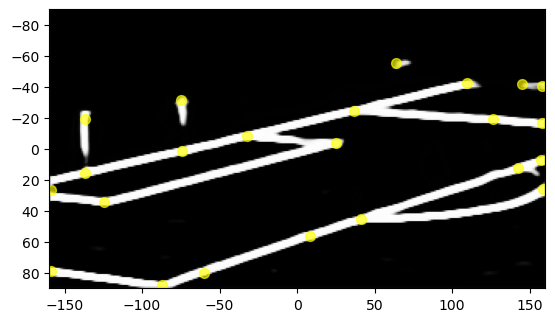

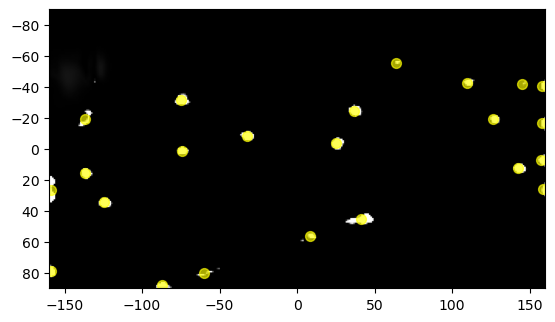

In [88]:
seg_mask = (seg_mask - seg_mask.min()) / (seg_mask.max() - seg_mask.min())
keypoint_mask = (keypoint_mask - keypoint_mask.min()) / (keypoint_mask.max() - keypoint_mask.min())

plt.figure()
plt.imshow(seg_mask, cmap='gray', extent=[-160, 160, 90, -90])
# plt.savefig('../reports/2510/masks/image-segmentation-mask-plain.png')
plt.scatter(x=out_keypoints[:, 1], y=out_keypoints[:, 0], color='yellow', marker='o', s=50, alpha=0.66)
# plt.savefig('../reports/2510/masks/image-segmentation-mask.png')
plt.show()

plt.figure()
plt.imshow(keypoint_mask, cmap='gray', extent=[-160, 160, 90, -90])
# plt.savefig('../reports/2510/masks/image-keypoint-mask-plain.png')
plt.scatter(x=out_keypoints[:, 1], y=out_keypoints[:, 0], color='yellow', marker='o', s=50, alpha=0.66)
# plt.savefig('../reports/2510/masks/image-keypoint-mask.png')
plt.show()

In [225]:
segments = []
for i in range(out_keypoints.shape[0]):
    for j in range(i + 1, out_keypoints.shape[0]):
        A, B = out_keypoints[[i, j]]
        n_iter = int(np.linalg.vector_norm(A - B))

        t = np.random.random(n_iter)
        X = np.outer((1 - t), A) + np.outer(t, B)
        X = X[:, [0, 1]] / X[:, [2]]
        X += np.array([[90, 160]])                  # Offset
        X += np.random.uniform(-1, 1, size=X.shape)
        X = np.round(X).astype('int')
        for dim in range(2):
            X[:, dim] = np.clip(X[:, dim], 0, seg_mask.shape[dim] - 1)

        pixels = seg_mask[X[:, 0], X[:, 1]] ** 0.1
        # print(pixels.shape)
        confidence = np.mean(pixels)
        if confidence > 0.80:
            segments.append((i, j, confidence))

print(len(segments))
segments = np.array(segments)
segments = np.sort(segments[:, [2, 0, 1]], axis=0)
segments = segments[::-1, [1, 2, 0]]
print(segments)
print(len(segments))

42
[[         19          22     0.99905]
 [         18          20     0.99896]
 [         17          20     0.99893]
 [         14          20     0.99892]
 [         13          20     0.99891]
 [         13          20     0.99891]
 [         13          19      0.9989]
 [         11          19     0.99889]
 [         10          19     0.99888]
 [         10          19     0.99887]
 [         10          19     0.99886]
 [         10          18     0.99885]
 [          8          17     0.99884]
 [          8          16     0.99882]
 [          8          16     0.99881]
 [          7          16     0.99881]
 [          7          15      0.9988]
 [          7          15      0.9988]
 [          7          15     0.99879]
 [          6          15     0.99876]
 [          6          15     0.99872]
 [          6          14     0.99869]
 [          5          14     0.99866]
 [          4          13     0.99861]
 [          4          13     0.99851]
 [          4         

[[    0.81189     0.58381     -50.553]
 [     0.8755     0.48322     -41.156]
 [    0.97088     0.23955     -63.419]
 [    0.88305     0.46928     -42.598]
 [    0.94855     0.31661     -57.006]
 [    0.94855     0.31661     -57.006]
 [    0.95047     0.31082     -56.107]
 [    0.83223    -0.55443     -42.308]
 [    0.94954     0.31365     -56.078]
 [    0.94954     0.31365     -56.078]
 [    0.94954     0.31365     -56.078]
 [    0.88641     0.46291     -37.504]
 [    0.99938   -0.035196     -20.644]
 [    0.99403      0.1091    -0.86029]
 [    0.99403      0.1091    -0.86029]
 [    0.47168     0.88177     -131.73]
 [    0.51135    -0.85937      116.22]
 [    0.51135    -0.85937      116.22]
 [    0.51135    -0.85937      116.22]
 [    0.97209     0.23462      15.721]
 [    0.97209     0.23462      15.721]
 [    0.99774    0.067231      10.486]
 [    0.97789     0.20911     -7.8543]
 [    0.96678    -0.25562      33.064]
 [    0.96678    -0.25562      33.064]
 [    0.96678    -0.25562

(-1.1, 1.1)

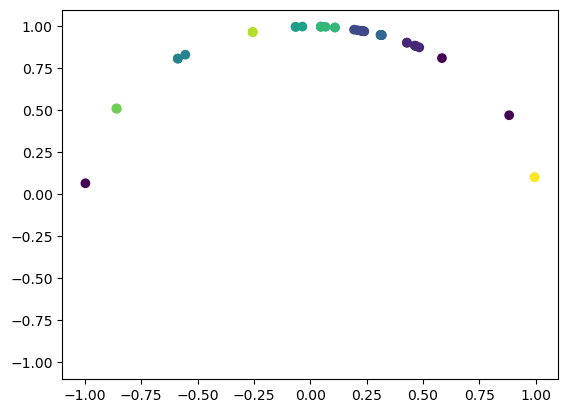

In [226]:
A, B, _ = segments.T.astype('int')
line = np.cross(out_keypoints[A], out_keypoints[B])
line[line[:, 0] < 0, :] *= -1
line = line / np.linalg.norm(line[:, [0, 1]], axis=1, keepdims=True)
print(line)

dbscan_arg = DBSCAN(min_samples=2, eps=0.05).fit(line[:, [0, 1]])
line_arg_labels = dbscan_arg.labels_

print(line_arg_labels)

plt.scatter(line[:, 1], line[:, 0], c=dbscan_arg.labels_)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

In [227]:
filtered_lines = []

for line_type in (0, 1):
    idxs = (line_arg_labels == line_type)
    z_comps = line[idxs, -1].reshape(-1, 1)
    idxs_center = AffinityPropagation(damping=.8).fit(z_comps).cluster_centers_indices_
    # print(line_type, line_center)

    filtered_lines.append(line[idxs][idxs_center])

filtered_lines

[array([[     0.8755,     0.48322,     -41.156],
        [    0.90364,     0.42829,      44.146]]),
 array([[    0.97088,     0.23955,     -63.419],
        [    0.97432,     0.22518,      15.568],
        [    0.98103,     0.19386,      45.349]])]

/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_15078/2815097667.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


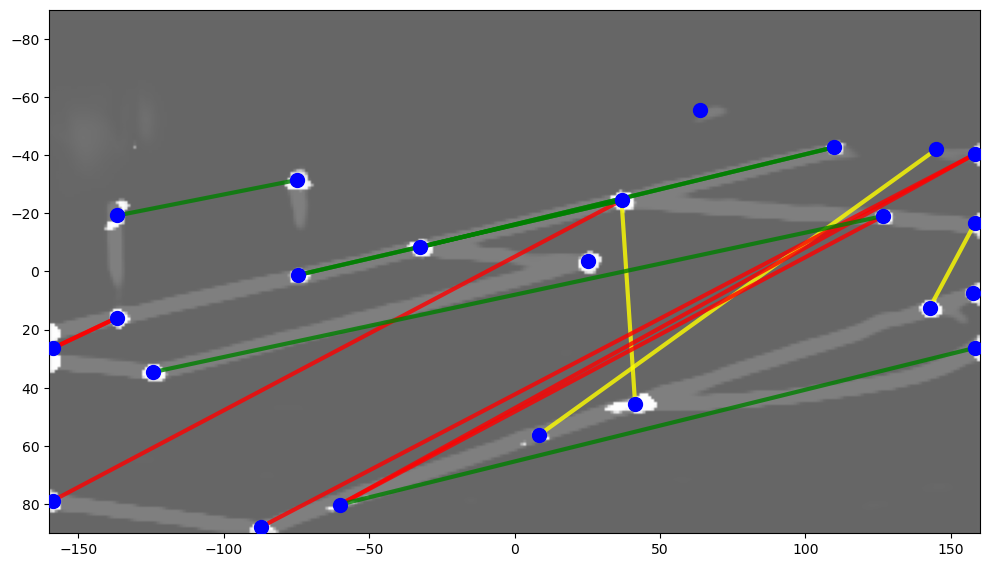

In [228]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')

X = np.stack([
    out_keypoints[segments[:, 0].astype('int'), 0:2],
    out_keypoints[segments[:, 1].astype('int'), 0:2]
], axis=1)

ax.scatter(x=out_keypoints[:, 1], y=out_keypoints[:, 0], color='blue', marker='o', s=100, zorder=10)
ax.plot(X[dbscan_arg.labels_ == -1, :, -1].T, X[dbscan_arg.labels_ == -1, :, 0].T, marker='o', color='yellow', linewidth=3, alpha=.8)
ax.plot(X[dbscan_arg.labels_ == 0, :, 1].T, X[dbscan_arg.labels_ == 0, :, 0].T, marker='o', color='red', linewidth=3, alpha=.8)
ax.plot(X[dbscan_arg.labels_ == 1, :, 1].T, X[dbscan_arg.labels_ == 1, :, 0].T, marker='o', color='green', linewidth=3, alpha=.8)
ax.imshow(seg_mask, cmap='gray', extent=[-160, 160, 90, -90], alpha=.2)
ax.imshow(keypoint_mask, cmap='gray', extent=[-160, 160, 90, -90], alpha=.5)
ax.set_xlim(-160, 160)
ax.set_ylim(90, -90)

fig.tight_layout()
# fig.savefig('../reports/2510/clustering/edge-detected.png')
fig.show()

In [229]:
def best_intersection_point(lines):
    _, _, VT = np.linalg.svd(lines)
    return VT[-1]

vp_0 = best_intersection_point(filtered_lines[0])
vp_1 = best_intersection_point(filtered_lines[1])
v_line = np.cross(vp_0, vp_1)

vp_0 /= vp_0[2]
vp_1 /= vp_1[2]
v_line /= v_line[2]

print(vp_0)
print(vp_1)
print(v_line)

[    -631.51      1229.3           1]
[    -576.39      2564.8           1]
[  0.0014657 -6.0501e-05           1]


In [230]:
homography_affine = np.eye(3)
homography_affine[2, :] = v_line
print(homography_affine)

[[          1           0           0]
 [          0           1           0]
 [  0.0014657 -6.0501e-05           1]]


In [231]:
out_keypoints_affine = out_keypoints @ homography_affine.T

X_affine = np.stack([
    out_keypoints_affine[segments[:, 0].astype('int'), 0:2],
    out_keypoints_affine[segments[:, 1].astype('int'), 0:2]
], axis=1)

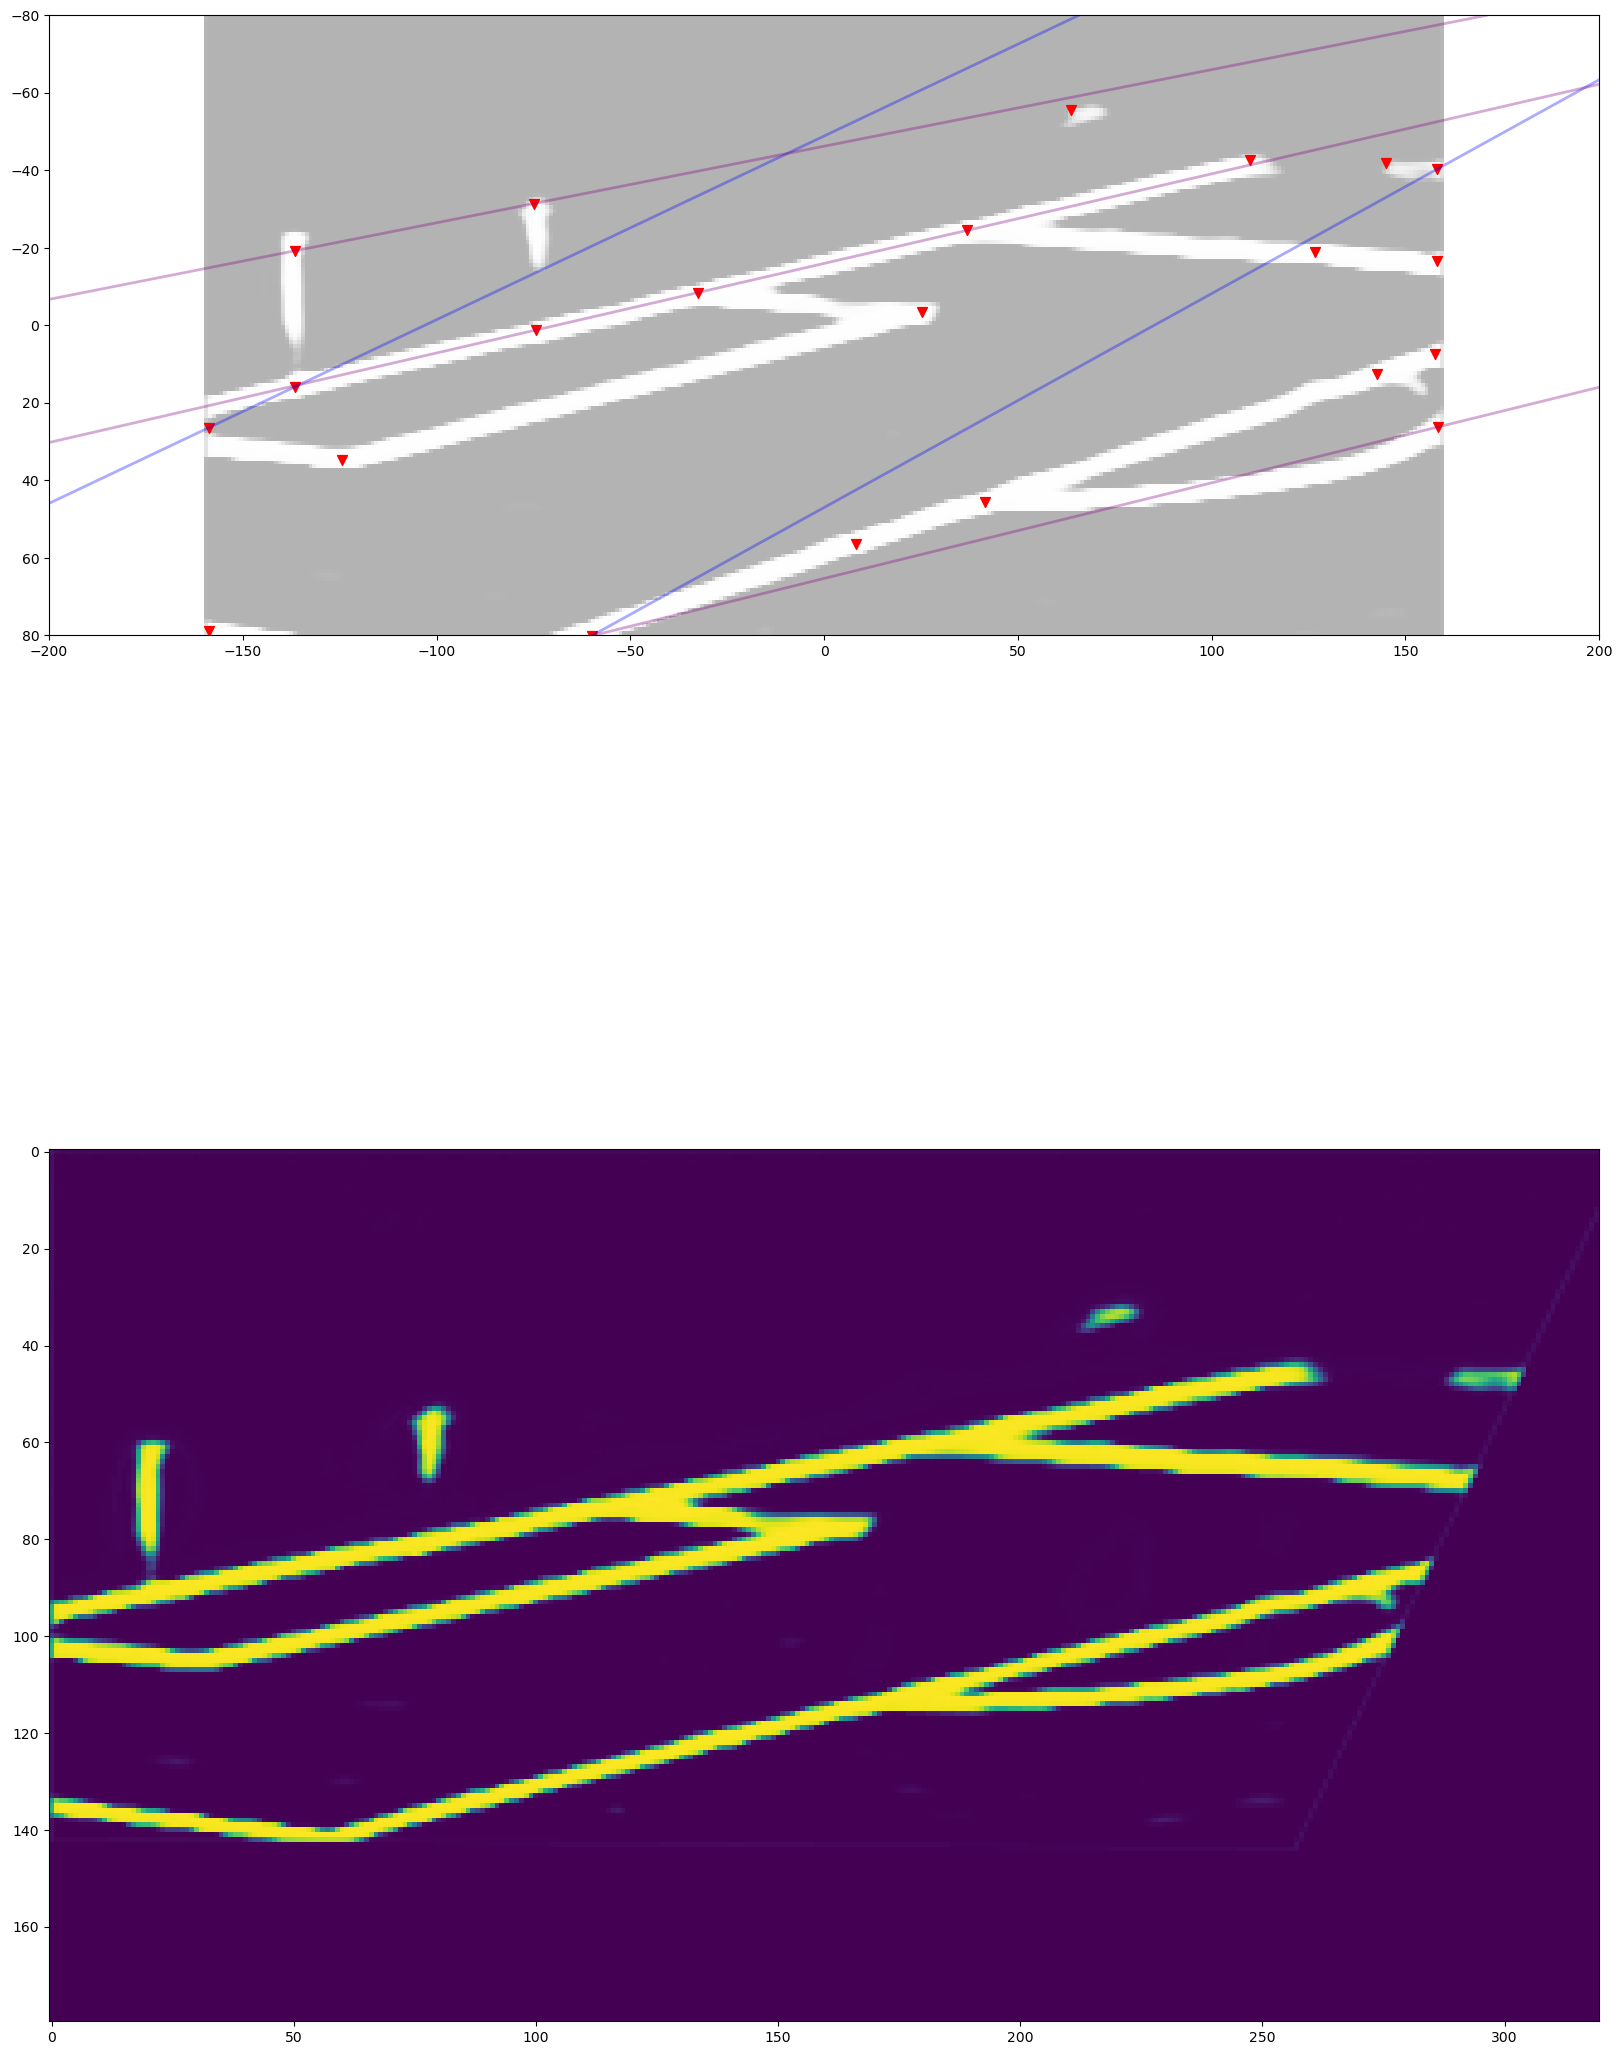

In [232]:
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(20, 30))
ax[0].imshow(seg_mask, cmap='gray', extent=[-160, 160, 90, -90], alpha=.3)
ax[0].scatter(x=out_keypoints[:, 1], y=out_keypoints[:, 0], color='red', marker='v', s=50)

COLOURS = ['blue', 'purple']
for line_type, line in enumerate(filtered_lines):
    for b, a, c in line:
        ax[0].axline((0, -c/b), (-c/a, 0), color=COLOURS[line_type], linewidth=2, alpha=.33)
    ax[0].axline(vp_0[[1, 0]], vp_1[[1, 0]], color='orange', linewidth=2, alpha=1)

ax[0].set_xlim(-200, 200)
ax[0].set_ylim(80, -80)

seg_affine_mask = cv2.warpPerspective(seg_mask, homography_affine[[1, 0, 2]][:, [1, 0, 2]], (320, 180))
ax[1].imshow(seg_affine_mask)

In [233]:
filtered_lines_affine = [filtered_lines_ @ homography_affine.T for filtered_lines_ in filtered_lines]
print(filtered_lines)
print(filtered_lines_affine)

[array([[     0.8755,     0.48322,     -41.156],
       [    0.90364,     0.42829,      44.146]]), array([[    0.97088,     0.23955,     -63.419],
       [    0.97432,     0.22518,      15.568],
       [    0.98103,     0.19386,      45.349]])]
[array([[     0.8755,     0.48322,     -41.155],
       [    0.90364,     0.42829,      44.148]]), array([[    0.97088,     0.23955,     -63.418],
       [    0.97432,     0.22518,       15.57],
       [    0.98103,     0.19386,       45.35]])]


In [234]:
filtered_lines_affine[0]

array([[     0.8755,     0.48322,     -41.155],
       [    0.90364,     0.42829,      44.148]])

In [235]:
coeffs_all = []
for line_0 in filtered_lines_affine[0]:
    for line_1 in filtered_lines_affine[1]:
        coeffs = np.array([
            line_0[0] * line_1[0],
            line_0[0] * line_1[1] + line_0[1] * line_1[0],
            line_0[1] * line_1[1],
        ])
        coeffs_all.append(coeffs)

coeffs_all = np.array(coeffs_all)
_, _, VT = np.linalg.svd(coeffs_all)

# Determine S = KK^T
S = VT[-1]
S = np.array([[S[0], S[1]], [S[1], S[2]]])

# Determine K via SVD (achievable via Cholesky too)
U, D, _ = np.linalg.svd(S)
D = np.diag(np.sqrt(D))
K = U @ D

print(f'S = {S}')
print(f'K @ K.T = {K @ K.T}')
print(f'K = {K}')

S = [[   0.095574    -0.27905]
 [   -0.27905     0.95551]]
K @ K.T = [[   0.095574    -0.27905]
 [   -0.27905     0.95551]]
K = [[   -0.28924     0.10915]
 [    0.97697    0.032316]]


In [236]:
homography_similarity = np.eye(3)
homography_similarity[0:2, 0:2] = K
homography_similarity

array([[   -0.28924,     0.10915,           0],
       [    0.97697,    0.032316,           0],
       [          0,           0,           1]])

In [237]:
homography_affine_similarity = homography_similarity @ homography_affine
homography_affine_similarity[2, :] *= 0.5
if np.linalg.det(homography_affine_similarity) * homography_affine_similarity[2, 2] < 0:
    homography_affine_similarity[0, :] *= -1

print(homography_affine_similarity)
print(np.linalg.det(homography_affine_similarity / homography_affine_similarity[2, 2]))

[[    0.28924    -0.10915          -0]
 [    0.97697    0.032316           0]
 [ 0.00073287  -3.025e-05         0.5]]
0.46394690143281464


In [238]:
out_keypoints_similarity = out_keypoints @ homography_affine_similarity.T
out_keypoints_similarity = out_keypoints_similarity / out_keypoints_similarity[:, [2]]
print(out_keypoints_similarity)

X_similarity = np.stack([
    out_keypoints_similarity[segments[:, 0].astype('int'), 0:2],
    out_keypoints_similarity[segments[:, 1].astype('int'), 0:2]
], axis=1)

[[     16.219      86.021           1]
 [     47.652      39.451           1]
 [    -1.9024     -69.108           1]
 [     -7.577     -5.0983           1]
 [    -23.066     -47.251           1]
 [     44.604      56.358           1]
 [     2.3197     -18.542           1]
 [    -23.674      33.376           1]
 [     37.781      21.468           1]
 [      19.06     -47.367           1]
 [     61.627      146.44           1]
 [     16.861     -2.3926           1]
 [      71.32      127.73           1]
 [    -30.044      24.769           1]
 [    -40.077     -30.091           1]
 [     -52.29     -81.976           1]
 [    -45.626     -22.783           1]
 [    -18.861      59.775           1]
 [    -62.102     -73.557           1]
 [     28.452      102.22           1]
 [     53.029      136.19           1]
 [    -50.393     -114.27           1]
 [    -60.184     -78.193           1]]


(100.0, -100.0)

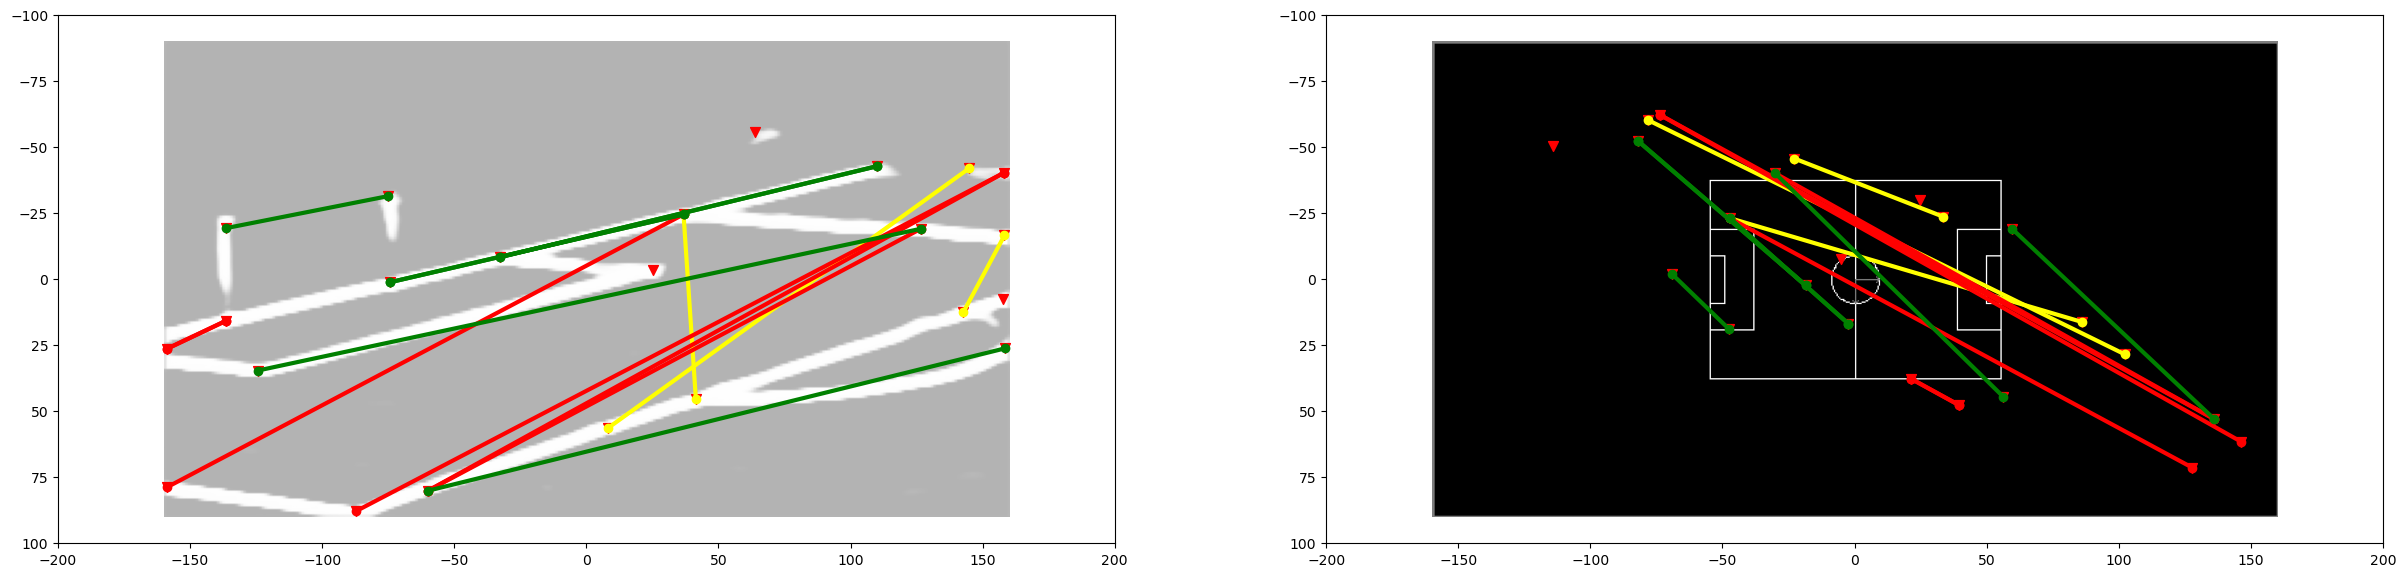

In [239]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(30, 30))

ax[0].plot(X[dbscan_arg.labels_ == -1, :, -1].T, X[dbscan_arg.labels_ == -1, :, 0].T, marker='o', color='yellow', linewidth=3)
ax[0].plot(X[dbscan_arg.labels_ ==  0, :,  1].T, X[dbscan_arg.labels_ ==  0, :, 0].T, marker='o', color='red', linewidth=3)
ax[0].plot(X[dbscan_arg.labels_ ==  1, :,  1].T, X[dbscan_arg.labels_ ==  1, :, 0].T, marker='o', color='green', linewidth=3)
ax[0].scatter(x=out_keypoints[:, 1], y=out_keypoints[:, 0], color='red', marker='v', s=50)
ax[0].imshow(seg_mask, cmap='gray', extent=[-160, 160, 90, -90], alpha=.3)
ax[0].set_xlim(-200, 200)
ax[0].set_ylim(100, -100)

ax[1].plot(X_similarity[dbscan_arg.labels_ == -1, :, -1].T, X_similarity[dbscan_arg.labels_ == -1, :, 0].T, marker='o', color='yellow', linewidth=3)
ax[1].plot(X_similarity[dbscan_arg.labels_ ==  0, :,  1].T, X_similarity[dbscan_arg.labels_ ==  0, :, 0].T, marker='o', color='red', linewidth=3)
ax[1].plot(X_similarity[dbscan_arg.labels_ ==  1, :,  1].T, X_similarity[dbscan_arg.labels_ ==  1, :, 0].T, marker='o', color='green', linewidth=3)
ax[1].scatter(x=out_keypoints_similarity[:, 1], y=out_keypoints_similarity[:, 0], color='red', marker='v', s=50)
ax[1].imshow(seg_affine_mask, cmap='gray', extent=[-160, 160, 90, -90], alpha=.3)
Pitch().plot(ax[1], scale=2)
ax[1].set_xlim(-200, 200)
ax[1].set_ylim(100, -100)

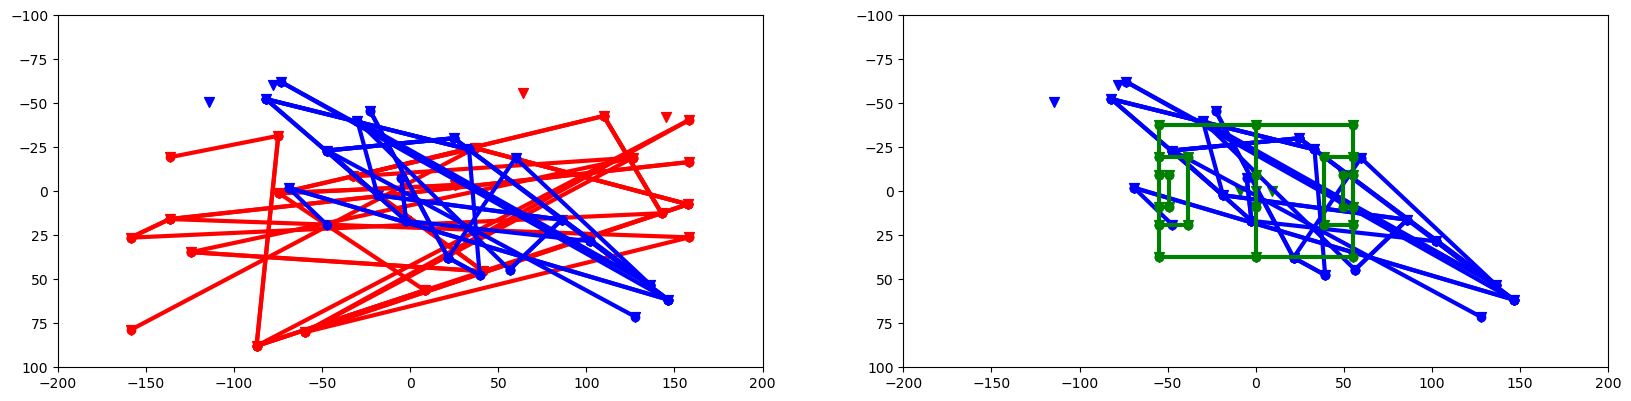

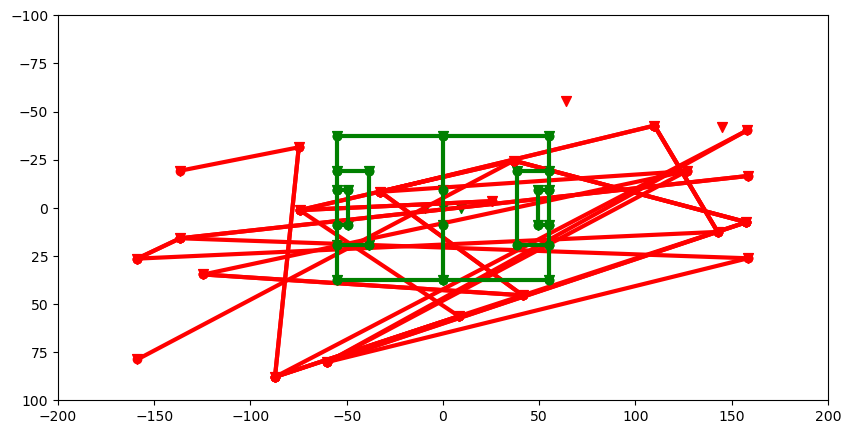

In [240]:
fig, ax = plt.subplots(ncols=2, figsize=(20, 15))

for idx in range(2):
    ax[idx].set_aspect('equal')
    ax[idx].set_xlim(-200, 200)
    ax[idx].set_ylim(100, -100)

main_segments = segments[dbscan_arg.labels_ != -1, :]

original_frame = FrameNumpy(out_keypoints, main_segments)
original_frame.plot(ax[0], color_pts='red', color_seg='red')

similar_frame = FrameNumpy(out_keypoints_similarity, main_segments)
deepcopy(original_frame).apply_homography(homography_affine_similarity).plot(ax[0], color_pts='blue', color_seg='blue')
similar_frame.plot(ax[1], color_pts='blue', color_seg='blue')

pitch_frame = Pitch().to_frame_numpy()
pitch_frame.plot(ax[1], color_pts='green', color_seg='green')


fig, ax2 = plt.subplots(figsize=(10, 5))
ax2.set_aspect('equal')
ax2.set_xlim(-200, 200)
ax2.set_ylim(100, -100)

original_frame.plot(ax2, color_pts='red', color_seg='red')
pitch_frame.plot(ax2, color_pts='green', color_seg='green')

In [241]:
def find_optimal_similarity_transform(frame_p, frame_q, INLIER_THRESHOLD=1, verbose=0):
    def _all_matches():
        for segment_p in frame_p.segments:
            p1, p2, _ = segment_p.astype('int')
            p1, p2 = frame_p.points[[p1, p2], 0:2]
            pv = p2 - p1
            # pv /= np.linalg.vector_norm(pv)

            for segment_q in frame_q.segments:
                q1, q2, _ = segment_q.astype('int')
                q1, q2 = frame_q.points[[q1, q2], 0:2]
                qv = q2 - q1
                # qv /= np.linalg.vector_norm(qv)

                yield (p1, q1), (p2, q2)
                yield (p1, q2), (p2, q1)
            
    def _left_matrix(p):
        px, py = p
        return np.array([
            [px, -py, 1, 0],
            [py, px, 0, 1]
        ])

    best_H = None
    best_inlier = -1

    # RANSAC
    for (p1, q1), (p2, q2) in _all_matches():
        A = np.concatenate([_left_matrix(p1), _left_matrix(p2)])
        m = np.concatenate([q1, q2])
        a, b, c, d = np.linalg.lstsq(A, m)[0]
        H = np.array([
            [a, -b, c],
            [b, a, d],
            [0, 0, 1]
        ])

        transformed_frame_p = deepcopy(frame_p).apply_homography(H)
        matched_segments_p = set()
        matched_segments_q = set()
        
        for idx_q, segment_q in enumerate(frame_q.segments):
            q1_, q2_, _ = segment_q.astype('int')
            q1_, q2_ = frame_q.points[[q1_, q2_], 0:2]
            qv_ = q2_ - q1_
            qv_ /= np.linalg.vector_norm(qv_)

            for idx_p, segment_p in enumerate(transformed_frame_p.segments):
                p1_, p2_, _ = segment_p.astype('int')
                p1_, p2_ = transformed_frame_p.points[[p1_, p2_], 0:2]
                # pv /= np.linalg.vector_norm(pv)

                is_inlier = False

                p1_dist = np.linalg.vector_norm((q1_ - p1_) - (np.dot(q1_ - p1_, qv_)) * qv_)
                p2_dist = np.linalg.vector_norm((q2_ - p2_) - (np.dot(q2_ - p2_, qv_)) * qv_)

                p1_in_segment_q = p1_dist <= INLIER_THRESHOLD
                p2_in_segment_q = p2_dist <= INLIER_THRESHOLD

                # print(p1_dist, p2_dist)

                if p1_dist + p2_dist <= 2 * INLIER_THRESHOLD:
                    matched_segments_p.add(idx_p)
                    matched_segments_q.add(idx_q)
                    # print(f'Inlier: Segment({p1_}, {p2_}) --> Segment({q1_}, {q2_})')

        count_inlier = len(matched_segments_p) + len(matched_segments_q)
        if count_inlier > best_inlier:
            best_inlier = count_inlier
            best_H = H
            
            if verbose > 0:
                print(p1, q1, p2, q2, len(matched_segments_p), '/', len(frame_p.segments), '+', len(matched_segments_q), '/', len(frame_q.segments))

        # print(p1, q1, p2, q2, len(matched_segments_p), '/', len(frame_p.segments), '+', len(matched_segments_q), '/', len(frame_q.segments))

    return best_H

homography_true = find_optimal_similarity_transform(similar_frame, pitch_frame)
homography_true

KeyboardInterrupt: 

In [ ]:
homography_rectification = homography_true @ homography_affine_similarity
homography_transform = np.linalg.inv(homography_rectification)

homography_rectification /= homography_rectification[2, 2]
homography_transform /= homography_transform[2, 2]

print(homography_rectification)
print(homography_transform, np.linalg.det(homography_transform))

[[    0.15566      1.0701     -36.842]
 [   -0.23322      1.5974         -55]
 [  0.0042404   -0.029044           1]]
[[ 7.6084e-08 -7.4467e-15  2.8031e-06]
 [ 6.8561e-08       0.626       34.43]
 [ 1.6687e-09    0.018182           1]] 1.130177524205076e-15


/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_15078/1786892062.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/sam/NUS/2510/NUSC-ISC-FootballAnalysis/scripts/classes/pitch/pitch.py:149: RuntimeWarning: invalid value encountered in cast
  polys = np.array(polys, dtype='int32')


KeyboardInterrupt: 

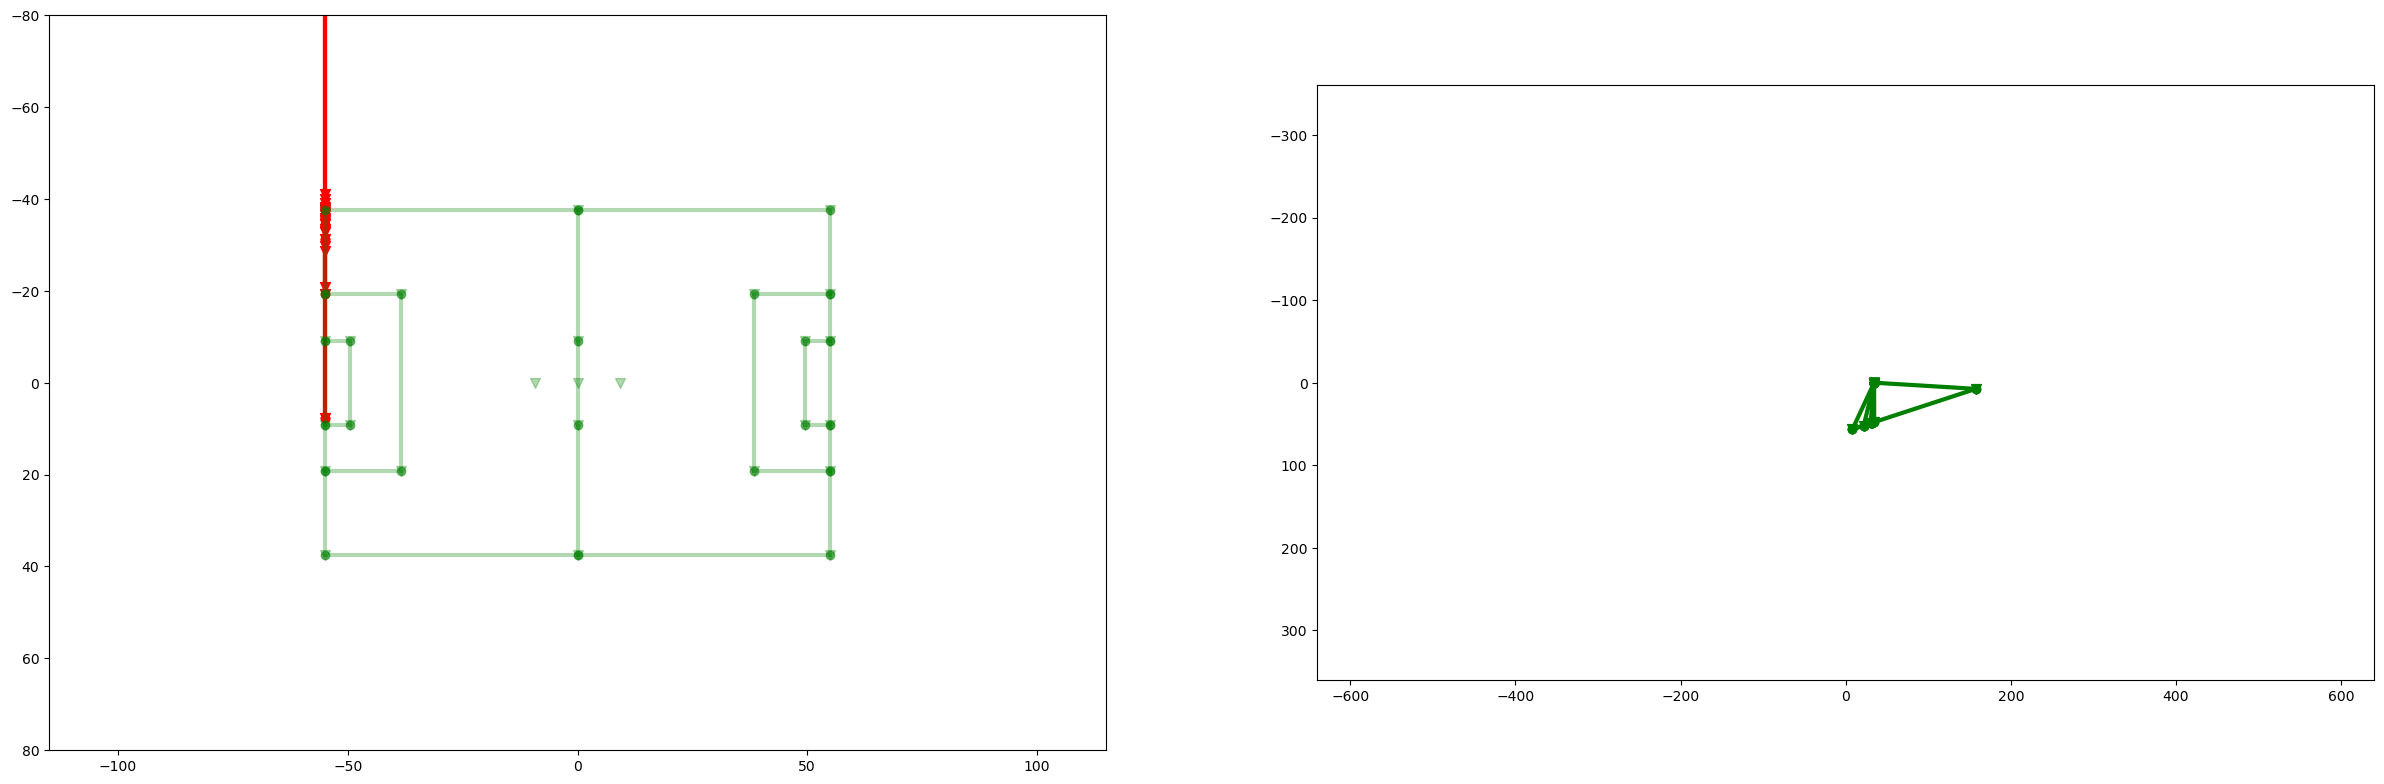

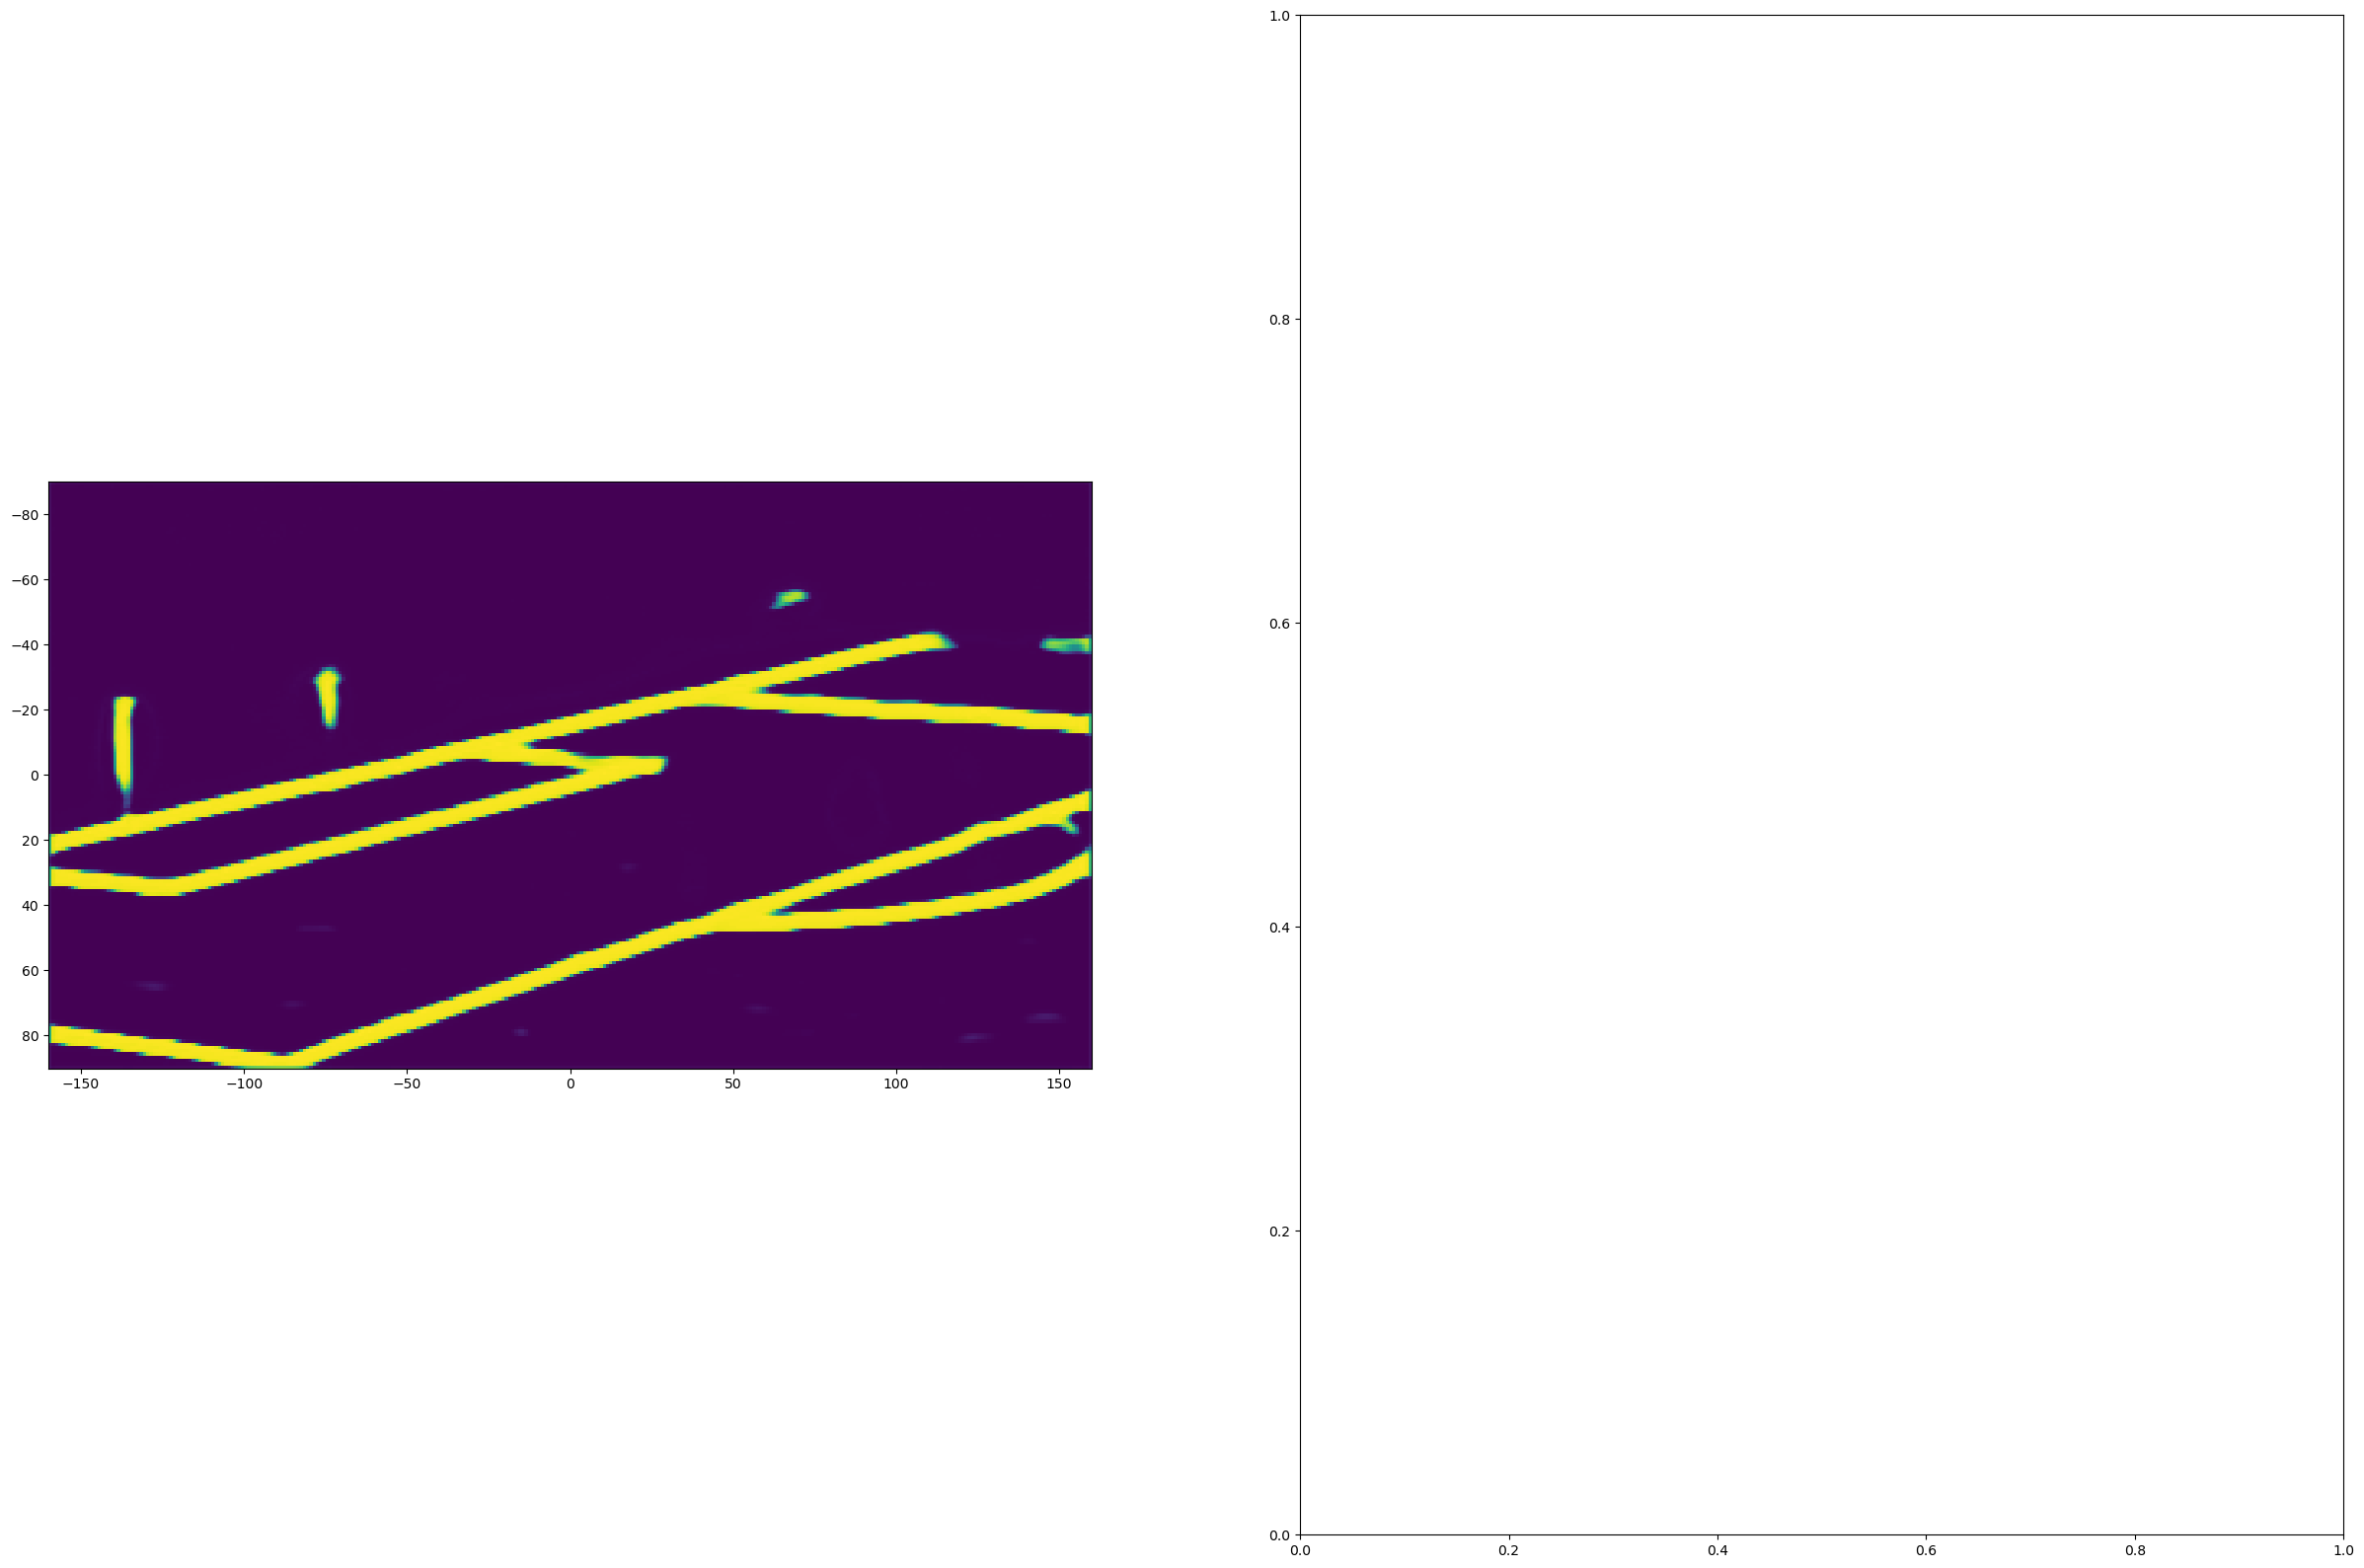

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(30, 20))
for idx in range(2):
    ax.flat[idx].set_aspect('equal')
    ax.flat[idx].set_xlim(-115, 115)
    ax.flat[idx].set_ylim(80, -80)

deepcopy(original_frame).apply_homography(homography_rectification).plot(ax[0], color_pts='red', color_seg='red')
pitch_frame.plot(ax[0], color_pts='green', color_seg='green', alpha=0.3)

deepcopy(pitch_frame) \
    .apply_homography(np.linalg.inv(homography_rectification)) \
    .plot(ax[1], color_pts='green', color_seg='green')
ax[1].set_xlim(-640, 640)
ax[1].set_ylim(360, -360)
fig.show()


fig, ax = plt.subplots(ncols=2, figsize=(30, 20))
transformed_pitch_frame = deepcopy(pitch_frame).apply_homography(homography_transform)

# p = pitch_frame.points[PitchKeypointMapping.RIGHT_GOALKEEPER_BOTTOM_RIGHT]
# q = transformed_pitch_frame.points[PitchKeypointMapping.RIGHT_GOALKEEPER_BOTTOM_RIGHT]
# p2 = pitch_frame.points[PitchKeypointMapping.RIGHT_PENALTY_BOTTOM_RIGHT]
# q2 = transformed_pitch_frame.points[PitchKeypointMapping.RIGHT_PENALTY_BOTTOM_RIGHT]

# p_ = p @ homography_transform.T
# p_ /= p_[2]

# p2_ = p2 @ homography_transform.T
# p2_ /= p2_[2]

# print(homography_transform)
# print(p)
# print(homography_transform.dot(p))
# print(p_)
# print('--------')
# print(p2)
# print(homography_transform.dot(p2))
# print(p2_)

ax[0].imshow(seg_mask, extent=[-160, 160, 90, -90])
Pitch().apply_homography(torch.Tensor(homography_transform)).plot(ax[1], scale=2, thickness=3)
fig.show()


In [ ]:
homography_transform

array([[     5.0931,       3.821,      250.37],
       [    -15.733,       20.97,      1028.7],
       [ -0.0074431,   -0.015229,           1]])